# 6. Скорость, память и анализ ошибок

Скорость уже измерена на RTX 3050 Laptop и CPU AMD Ryzen 5 5600U с четырьмя потоками. Benchmark использовал 20 одинаковых готовых test-окон и четыре прогревочных, batch=1. Время включает чтение и обработку JPEG, но не загрузку видео и извлечение кадров.

Код: `benchmark_vk_bundle.py`, `make_vk_casebook.py`, `build_vk_review_queue.py`, `plot_vk_tradeoff.py`. Повторный benchmark здесь не запускается.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts/train_vk_bundle.py").is_file()
             and (p / "configs/experiment_index.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Запустите ноутбук внутри sports_video_repo")

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def load_jsonl(path):
    return [json.loads(line) for line in (ROOT / path).read_text(encoding="utf-8").splitlines() if line]

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})
print("Читаем сохранённые результаты; обучение и скачивание не запускаются.")

Читаем сохранённые результаты; обучение и скачивание не запускаются.


,модель,GPU мс/окно,CPU мс/окно,"GPU VRAM, МиБ","CPU RSS процесса, МиБ","checkpoint, МиБ"
0,resnet18_1f,11.49,27.18,79.29,771.90,42.73
1,dinov2_1f,28.95,74.83,99.74,1380.91,84.25
2,x3d_shortside_4f,47.75,52.14,24.94,756.90,7.98
3,r3d18_16f,36.23,386.23,221.24,941.96,126.62


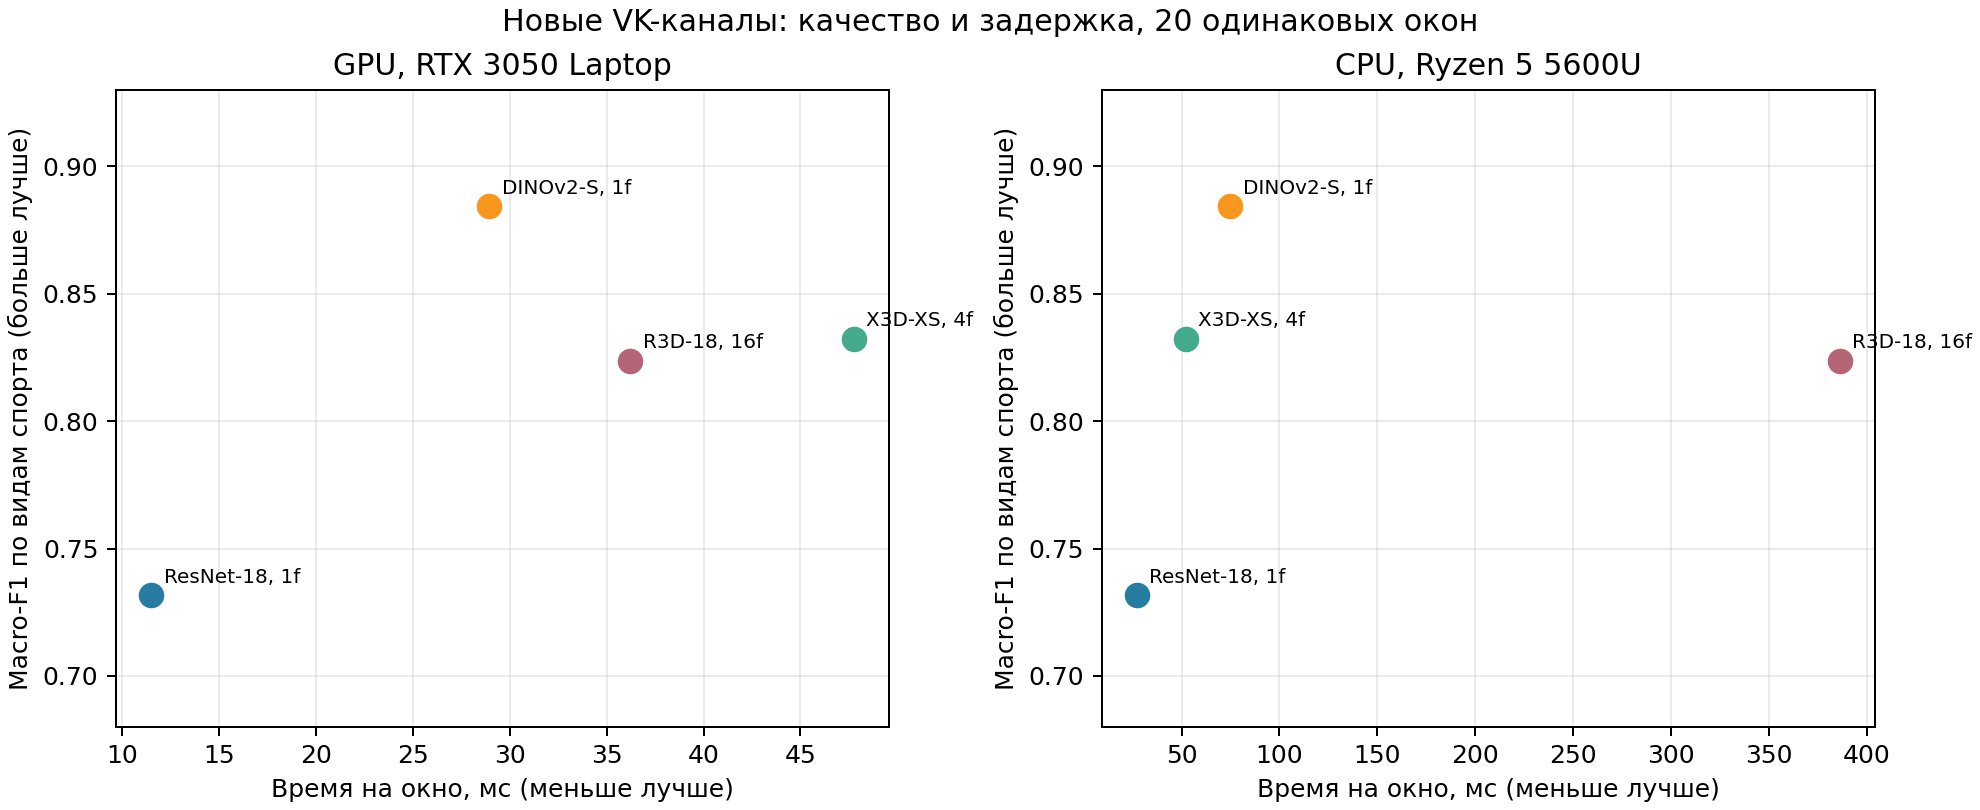

In [2]:
runs = ["vk_owner_resnet18_1f", "vk_owner_dinov2_1f", "vk_owner_x3d_shortside_4f", "vk_owner_r3d18_16f"]
table = []
for run in runs:
    gpu, cpu = load_json(f"outputs/{run}/benchmark.json"), load_json(f"outputs/{run}/benchmark_cpu.json")
    met = load_json(f"outputs/{run}/test_metrics.json")
    table.append({"модель": run.replace("vk_owner_", ""),
        "GPU мс/окно": gpu["end_to_end_ms_per_clip"], "CPU мс/окно": cpu["end_to_end_ms_per_clip"],
        "GPU VRAM, МиБ": gpu["peak_inference_vram_mb"], "CPU RSS процесса, МиБ": cpu["peak_cpu_rss_mb"],
        "checkpoint, МиБ": met["efficiency"]["checkpoint_mb"]})
display(pd.DataFrame(table).round(2))
display(Image(filename=str(ROOT / "outputs/vk_quality_speed.png"), width=900))

## Ошибки основного кандидата DINOv2 1f

In [3]:
metrics = load_json("outputs/vk_owner_dinov2_1f/test_metrics.json")["group"]
classes = {"sport": ["basketball", "football", "handball", "table_tennis", "tennis", "volleyball"],
           "gender": ["men", "women"], "age": ["under_18", "adult_18_plus"]}
for task, labels in classes.items():
    display(Markdown(f"**{task}: строки — метки, столбцы — прогнозы**"))
    display(pd.DataFrame(metrics[task]["confusion_matrix"], index=labels, columns=labels))

**sport: строки — метки, столбцы — прогнозы**

,basketball,football,handball,table_tennis,tennis,volleyball
basketball,9,0,3,0,0,1
football,0,7,0,0,0,0
handball,0,0,7,0,0,1
table_tennis,0,0,0,8,0,0
tennis,0,0,0,0,16,0
volleyball,2,0,0,0,0,7


**gender: строки — метки, столбцы — прогнозы**

,men,women
men,23,10
women,10,18


**age: строки — метки, столбцы — прогнозы**

,under_18,adult_18_plus
under_18,21,5
adult_18_plus,9,26


In [4]:
predictions = load_json("outputs/vk_owner_dinov2_1f/group_predictions.json")
errors = []
for p in predictions:
    wrong = [task for task in classes if p[task]["true"] != p[task]["pred"]]
    if wrong:
        errors.append({"группа": p["source_group_id"], "ошибки": ", ".join(wrong),
            **{task: f"{p[task]['true']} → {p[task]['pred']}" for task in classes}})
display(pd.DataFrame(errors).head(12))
print("Групп хотя бы с одним несовпадением:", len(errors), "из", len(predictions))

,группа,ошибки,sport,gender,age
0,c004711dc6a2f7053b88,gender,basketball → basketball,women → men,under_18 → under_18
1,cb98003a92a7fda10674,"sport, age",volleyball → basketball,men → men,adult_18_plus → under_18
2,4e95fd34673b69f7697e,gender,volleyball → volleyball,women → men,under_18 → under_18
3,88a008edfc973877dd32,"sport, gender, age",volleyball → basketball,women → men,under_18 → adult_18_plus
4,779c0f3d171e1908bb2a,gender,tennis → tennis,men → women,adult_18_plus → adult_18_plus
5,8cd23a2c6a36dfb08b98,sport,basketball → volleyball,men → men,under_18 → under_18
6,343dd52a5f2955c74fd1,sport,basketball → handball,men → men,under_18 → under_18
7,89352b08710137f0fd1f,gender,basketball → basketball,women → men,under_18 → under_18
8,5c96d6df2452289f65d5,age,basketball → basketball,men → men,under_18 → adult_18_plus
9,4d90399f4680468b044e,"gender, age",basketball → basketball,women → men,adult_18_plus → under_18


Групп хотя бы с одним несовпадением: 29 из 61


## Уже просмотренные качественные примеры

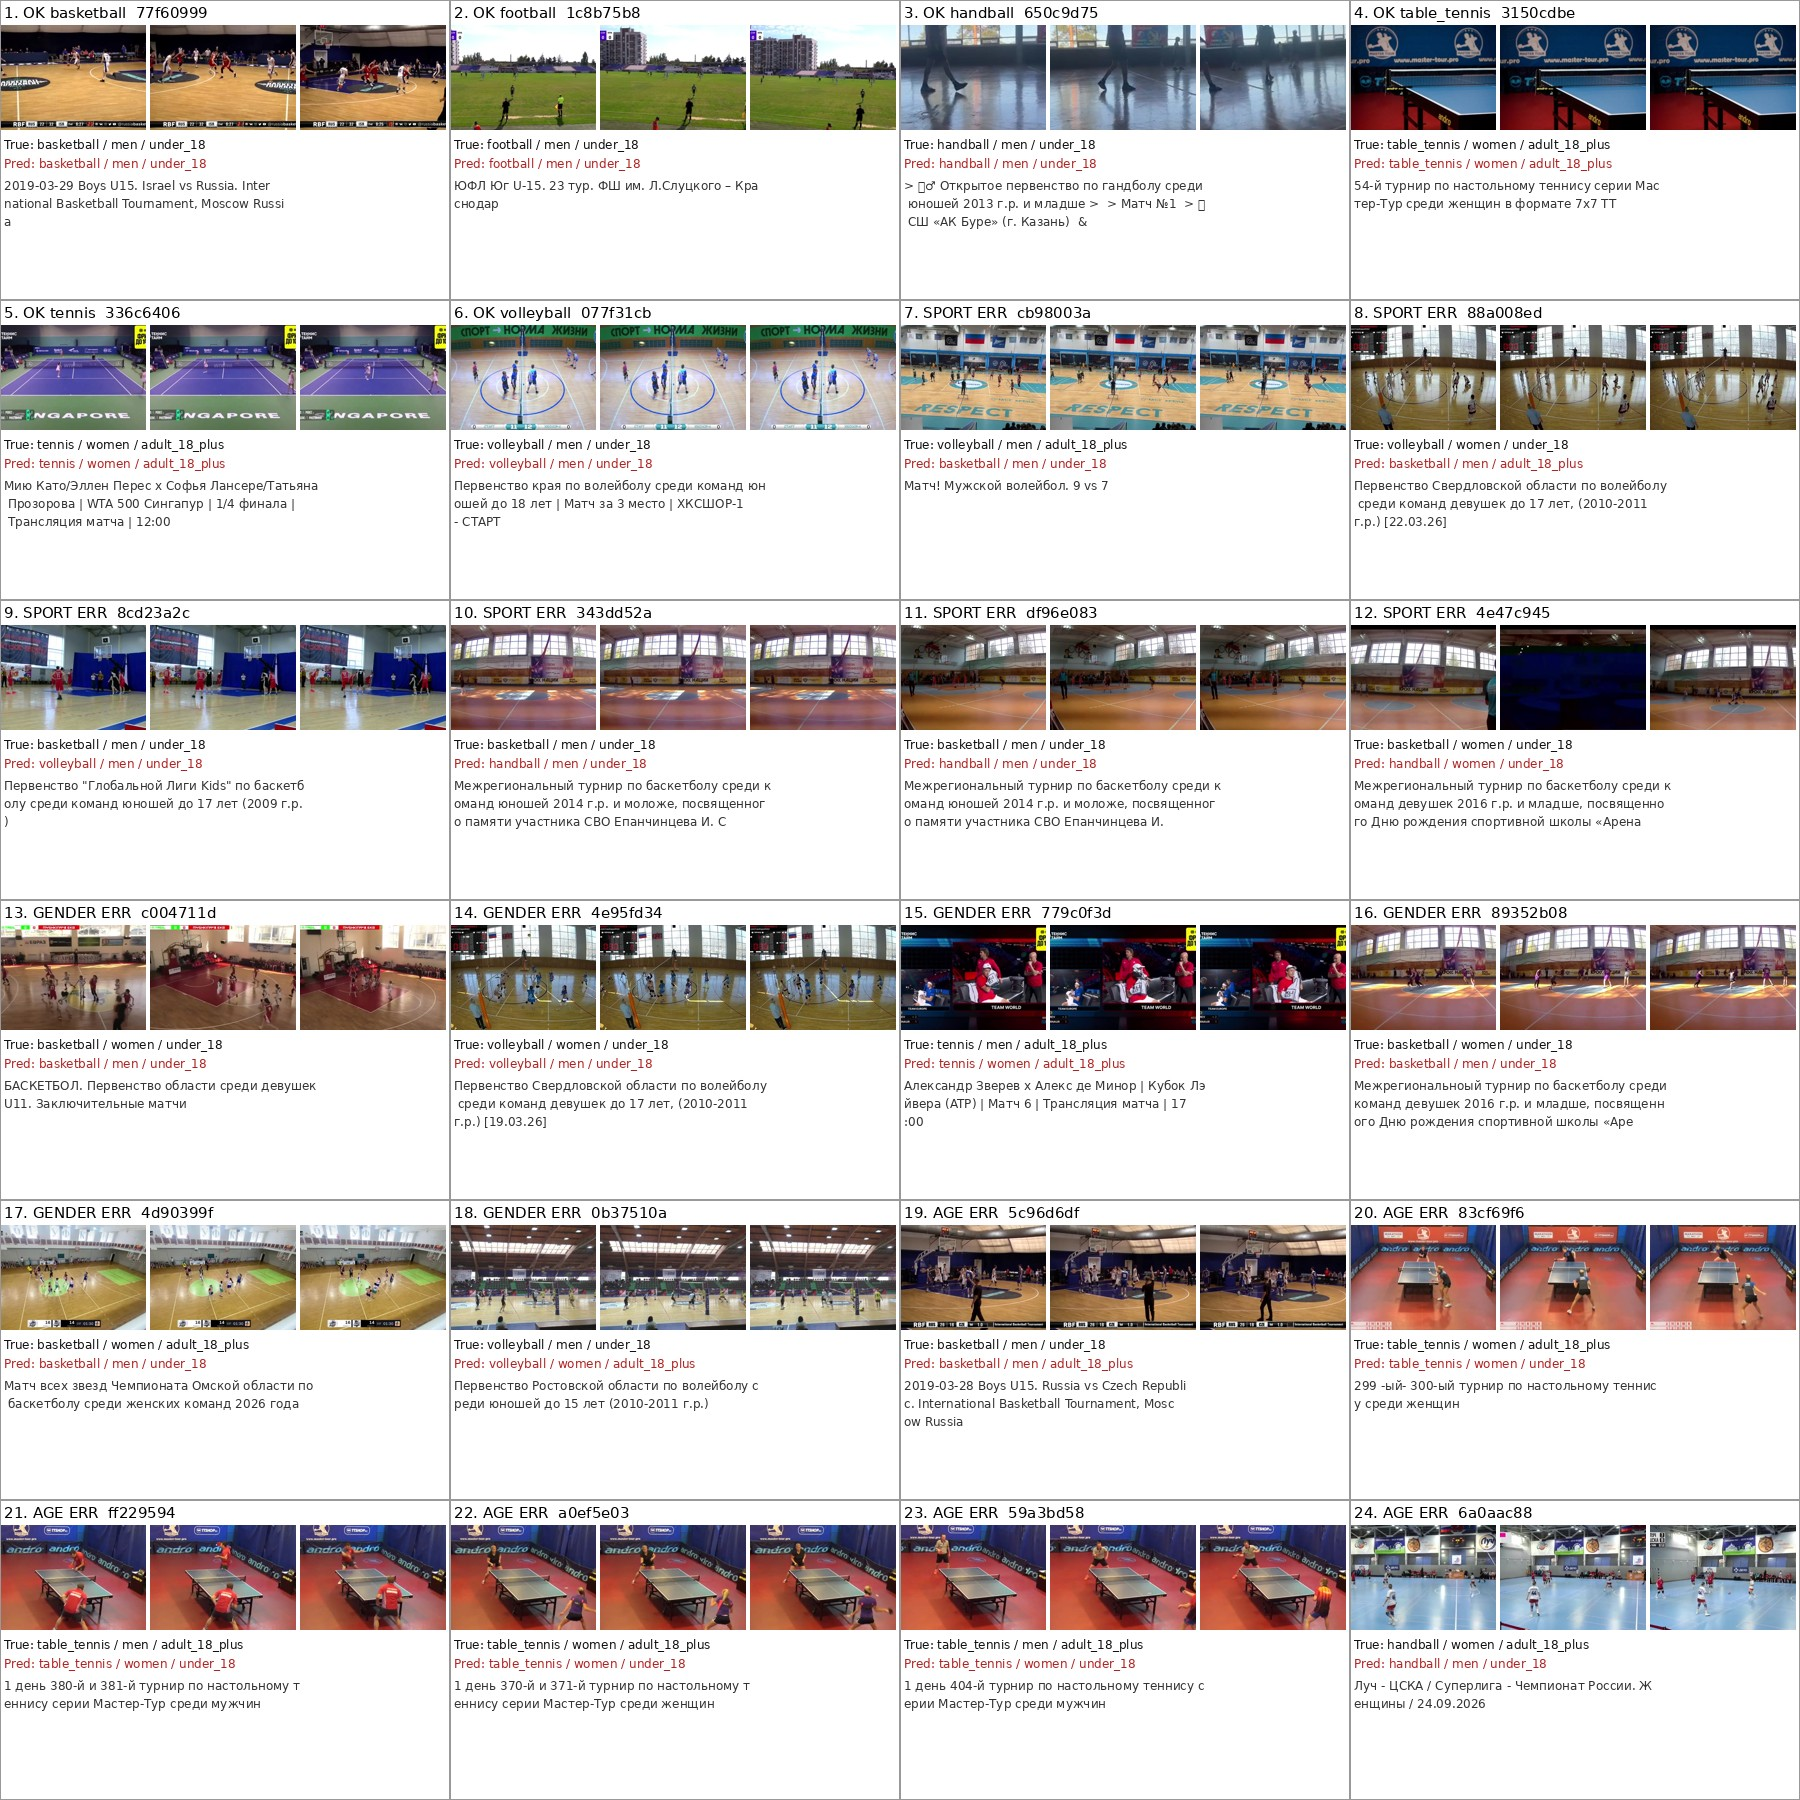

,tag,group,title
0,OK basketball,77f60999d0f06bf0501c,2019-03-29 Boys U15. Israel vs Russia. Interna...
1,OK football,1c8b75b8adec1e595d35,ЮФЛ Юг U-15. 23 тур. ФШ им. Л.Слуцкого – Красн...
2,OK handball,650c9d7503e92887edbe,> 🤾‍♂️ Открытое первенство по гандболу среди ю...
3,OK table_tennis,3150cdbe4b1a0b89b836,54-й турнир по настольному теннису серии Масте...
4,OK tennis,336c6406e79968898db2,Мию Като/Эллен Перес х Софья Лансере/Татьяна П...
5,OK volleyball,077f31cbf9476f1b9137,Первенство края по волейболу среди команд юнош...
6,SPORT ERR,cb98003a92a7fda10674,Матч! Мужской волейбол. 9 vs 7
7,SPORT ERR,88a008edfc973877dd32,Первенство Свердловской области по волейболу с...
8,SPORT ERR,8cd23a2c6a36dfb08b98,"Первенство ""Глобальной Лиги Kids"" по баскетбол..."
9,SPORT ERR,343dd52a5f2955c74fd1,Межрегиональный турнир по баскетболу среди ком...


In [5]:
display(Image(filename=str(ROOT / "outputs/vk_casebook/contact_sheet.jpg"), width=1000))
selection = load_json("outputs/vk_casebook/selection.json")
display(pd.DataFrame(selection)[["tag", "group", "title"]])

Зальные баскетбол, волейбол и гандбол путаются на дальних планах. В некоторых окнах есть тёмный переход или почти пустой зал. Для пола и возраста причина ошибки может быть как в визуальной неоднозначности, так и в слабой текстовой метке.

Один кадр DINOv2 может попасть на неудачный момент. Усреднение ответов окон уменьшает этот риск, но не устраняет его. Ручная проверка всего test не выполнена, а число независимых групп мало. Поэтому итоговые метрики показывают согласие со слабой разметкой.

[Подробный разбор](../docs/results/VK_CASE_ANALYSIS.md). [Демо](../demo/VK_DINOV2_DEMO.ipynb) пересчитывает прогнозы DINOv2 4f для шести заранее выбранных случаев; эти случаи не используются как отдельная оценка качества.